

# Importações



Todas as importações que serão utilizadas no decorrer do codigo

In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Estilo dos gráficos
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
pd.set_option("display.max_columns", None)  # Mostrar todas as colunas no df


# Leitura / Descompactação do arquivo

In [2]:
def descompactar_arquivos(nome_arquivo_zip, destino):
  """
  Descompacta um arquivo zip.

  Args:
    divulgacao_anos_finais_municipios_2023(1).zip: O nome do arquivo zip a ser descompactado.
    destino: O diretório onde os arquivos serão extraídos.
  """
  try:
    with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
      zip_ref.extractall(destino)
    print(f"Arquivo {nome_arquivo_zip} descompactado com sucesso para {destino}")
  except FileNotFoundError:
    print(f"Arquivo {nome_arquivo_zip} não encontrado.")
  except Exception as e:
    print(f"Erro ao descompactar o arquivo: {e}")

In [3]:
zip_prefeitos = "/content/divulgacao_anos_finais_municipios_2023.zip"
descompactar_arquivos( zip_prefeitos, './files_cand')

Arquivo /content/divulgacao_anos_finais_municipios_2023.zip descompactado com sucesso para ./files_cand


In [4]:
df_base = pd.read_excel("/content/files_cand/divulgacao_anos_finais_municipios_2023/divulgacao_anos_finais_municipios_2023.xlsx",skiprows=9)

# Filtragem da Região Norte/ redes válidas / Notas 05 e 23 do 1 ao 4 ano

In [5]:
# Filtro da Região Norte
estados_norte = ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO']
df_base = df_base[df_base['SG_UF'].isin(estados_norte)]

# Redes válidas
df_base = df_base[df_base['REDE'].isin(['Municipal', 'Estadual', 'Federal'])]

# Seleção das colunas realmente existentes (anos iniciais)
colunas_uteis = [
    'SG_UF', 'NO_MUNICIPIO', 'REDE',
    'VL_OBSERVADO_2005', 'VL_OBSERVADO_2023',
    'VL_NOTA_MATEMATICA_2005', 'VL_NOTA_MATEMATICA_2023',
    'VL_NOTA_PORTUGUES_2005', 'VL_NOTA_PORTUGUES_2023',
    'VL_APROVACAO_2005_1', 'VL_APROVACAO_2005_2', 'VL_APROVACAO_2005_3', 'VL_APROVACAO_2005_4',
    'VL_APROVACAO_2023_1', 'VL_APROVACAO_2023_2', 'VL_APROVACAO_2023_3', 'VL_APROVACAO_2023_4'
]

# Atualiza o df_base com apenas as colunas necessárias
df_base = df_base[colunas_uteis].copy()


# Limpeza de Dados

In [6]:
# Verificando se há valores nulos
print("🔍 Nulos antes do preenchimento:")
print(df_base.isnull().sum())

# Preenchendo os valores nulos com a média da própria coluna
df_base.fillna(df_base.mean(numeric_only=True), inplace=True)

# Verificando se ainda restaram nulos
print("\n✅ Nulos após o preenchimento:")
print(df_base.isnull().sum())


🔍 Nulos antes do preenchimento:
SG_UF                      0
NO_MUNICIPIO               0
REDE                       0
VL_OBSERVADO_2005          0
VL_OBSERVADO_2023          0
VL_NOTA_MATEMATICA_2005    0
VL_NOTA_MATEMATICA_2023    0
VL_NOTA_PORTUGUES_2005     0
VL_NOTA_PORTUGUES_2023     0
VL_APROVACAO_2005_1        0
VL_APROVACAO_2005_2        0
VL_APROVACAO_2005_3        0
VL_APROVACAO_2005_4        0
VL_APROVACAO_2023_1        0
VL_APROVACAO_2023_2        0
VL_APROVACAO_2023_3        0
VL_APROVACAO_2023_4        0
dtype: int64

✅ Nulos após o preenchimento:
SG_UF                      0
NO_MUNICIPIO               0
REDE                       0
VL_OBSERVADO_2005          0
VL_OBSERVADO_2023          0
VL_NOTA_MATEMATICA_2005    0
VL_NOTA_MATEMATICA_2023    0
VL_NOTA_PORTUGUES_2005     0
VL_NOTA_PORTUGUES_2023     0
VL_APROVACAO_2005_1        0
VL_APROVACAO_2005_2        0
VL_APROVACAO_2005_3        0
VL_APROVACAO_2005_4        0
VL_APROVACAO_2023_1        0
VL_APROVACAO_2023_2      

# Deltas

In [7]:
# Força conversão para número apenas nas colunas numéricas
colunas_numericas = [col for col in df_base.columns if 'VL_' in col or 'APROVACAO' in col]
df_base[colunas_numericas] = df_base[colunas_numericas].apply(pd.to_numeric, errors='coerce')


In [8]:
# Deltas de evolução entre 2005 e 2023
df_base['DELTA_IDEB'] = df_base['VL_OBSERVADO_2023'] - df_base['VL_OBSERVADO_2005']
df_base['DELTA_MT'] = df_base['VL_NOTA_MATEMATICA_2023'] - df_base['VL_NOTA_MATEMATICA_2005']
df_base['DELTA_LP'] = df_base['VL_NOTA_PORTUGUES_2023'] - df_base['VL_NOTA_PORTUGUES_2005']

# Média das taxas de aprovação dos anos iniciais (1º ao 4º)
df_base['APROVACAO_2005_MEDIA'] = df_base[[f'VL_APROVACAO_2005_{i}' for i in range(1, 5)]].mean(axis=1)
df_base['APROVACAO_2023_MEDIA'] = df_base[[f'VL_APROVACAO_2023_{i}' for i in range(1, 5)]].mean(axis=1)
df_base['DELTA_APROVACAO'] = df_base['APROVACAO_2023_MEDIA'] - df_base['APROVACAO_2005_MEDIA']


# Normalização de valores Deltas

In [9]:
from sklearn.preprocessing import StandardScaler

# 1. Selecionando as colunas a serem normalizadas
colunas_para_normalizar = ['DELTA_IDEB', 'DELTA_MT', 'DELTA_LP', 'DELTA_APROVACAO']

# 2. Inicializando o StandardScaler para normalizar os dados
scaler = StandardScaler()

X_normalizado = scaler.fit_transform(df_base[colunas_para_normalizar])



# Visualizações Primarias

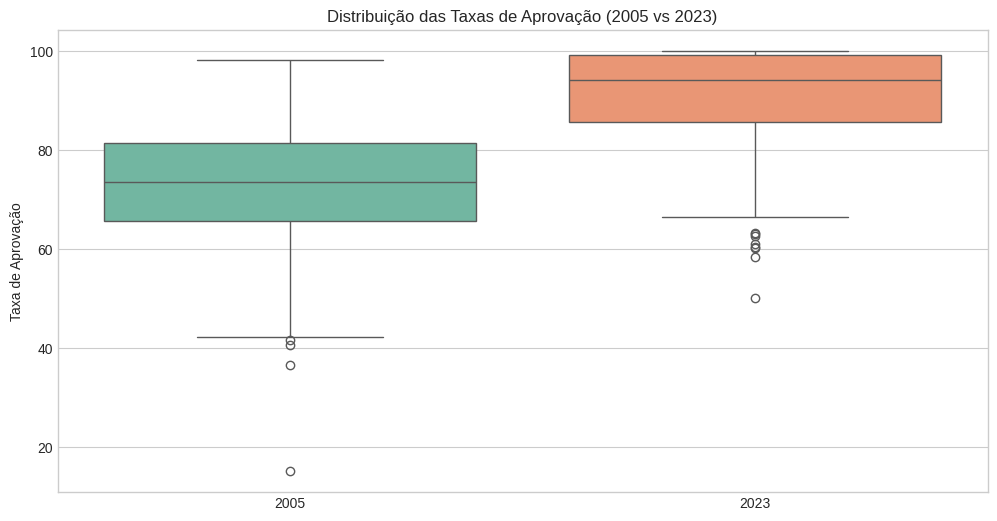

In [10]:
# 1. Distribuição das taxas de aprovação 2005 vs 2023
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_base[['VL_APROVACAO_2005_1', 'VL_APROVACAO_2023_1']])
plt.title("Distribuição das Taxas de Aprovação (2005 vs 2023)")
plt.ylabel("Taxa de Aprovação")
plt.xticks([0, 1], ['2005', '2023'])
plt.show()

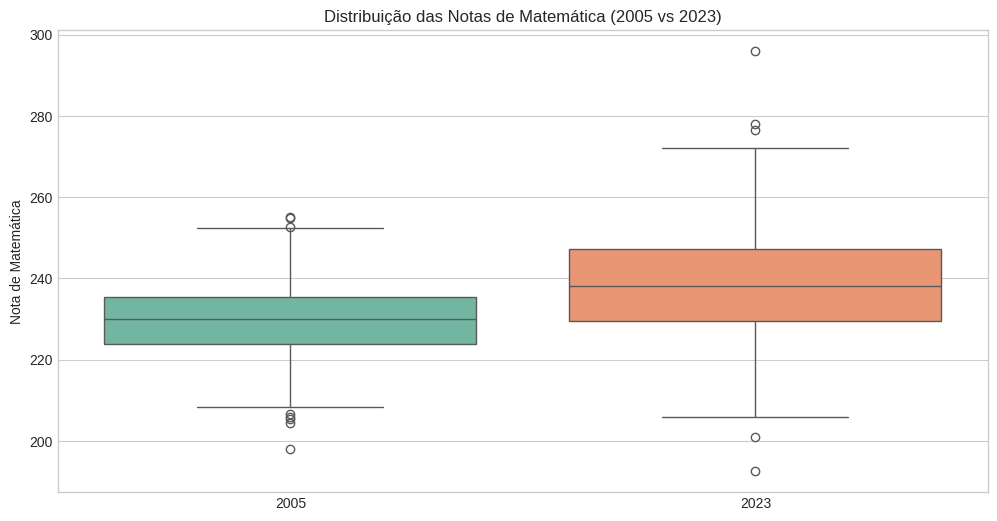

In [11]:
# 2. Distribuição das notas SAEB Matemática (2005 vs 2023)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_base[['VL_NOTA_MATEMATICA_2005', 'VL_NOTA_MATEMATICA_2023']])
plt.title("Distribuição das Notas de Matemática (2005 vs 2023)")
plt.ylabel("Nota de Matemática")
plt.xticks([0, 1], ['2005', '2023'])
plt.show()

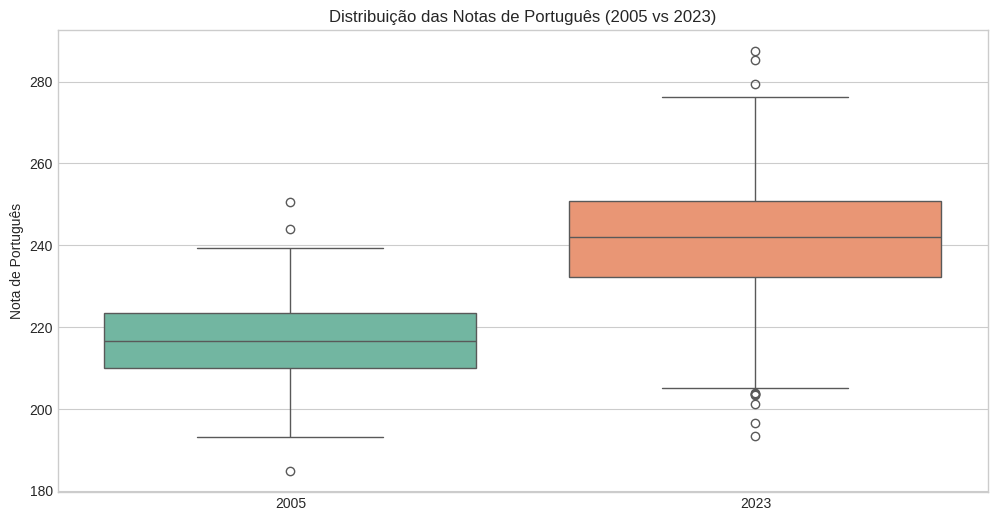

In [12]:
# 3. Distribuição das notas SAEB Português (2005 vs 2023)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_base[['VL_NOTA_PORTUGUES_2005', 'VL_NOTA_PORTUGUES_2023']])
plt.title("Distribuição das Notas de Português (2005 vs 2023)")
plt.ylabel("Nota de Português")
plt.xticks([0, 1], ['2005', '2023'])
plt.show()

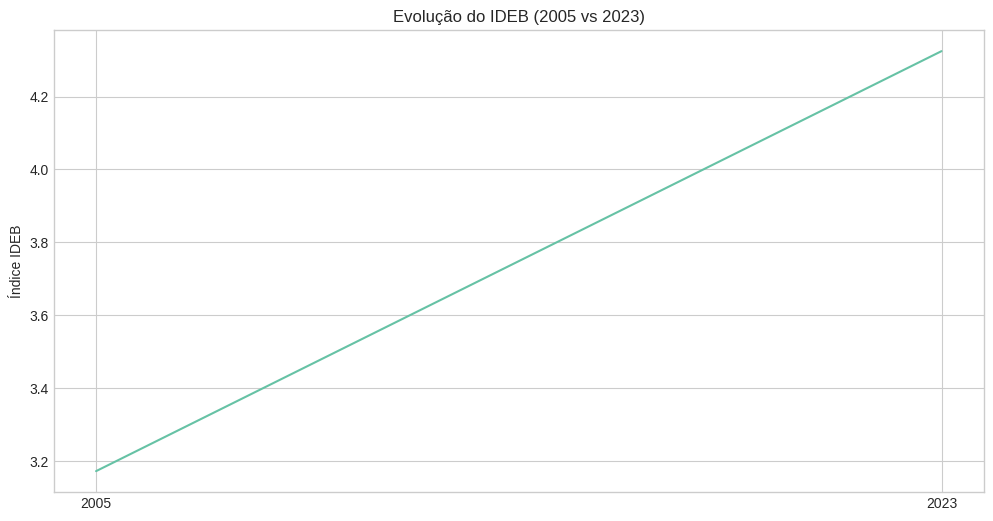

In [13]:
# 4. Evolução do IDEB de 2005 a 2023
plt.figure(figsize=(12, 6))
sns.lineplot(x=['2005', '2023'], y=[df_base['VL_OBSERVADO_2005'].mean(), df_base['VL_OBSERVADO_2023'].mean()])
plt.title("Evolução do IDEB (2005 vs 2023)")
plt.ylabel("Índice IDEB")
plt.show()

# Apriori

In [14]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Binarizando os dados para Apriori
df_apriori = df_base[['DELTA_IDEB', 'DELTA_MT', 'DELTA_LP', 'DELTA_APROVACAO']].copy()
df_apriori = df_apriori.applymap(lambda x: 1 if x > 0 else 0)

# Rodando o Apriori com um suporte mínimo de 10% (pode ajustar conforme necessidade)
frequent_itemsets = apriori(df_apriori, min_support=0.1, use_colnames=True)

# Gerando as regras de associação (usando o lift)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Traduzindo para o português
rules.rename(columns={
    'antecedents': 'Antecedentes',
    'consequents': 'Consequentes',
    'support': 'Suporte',
    'confidence': 'Confiança',
    'lift': 'Lift',
    'leverage': 'Alavancagem',
    'conviction': 'Convicção'
}, inplace=True)

# Exibindo as melhores regras
print(rules)


                               Antecedentes  \
0                              (DELTA_IDEB)   
1                                (DELTA_MT)   
2                                (DELTA_LP)   
3                              (DELTA_IDEB)   
4                              (DELTA_IDEB)   
5                         (DELTA_APROVACAO)   
6                                (DELTA_LP)   
7                                (DELTA_MT)   
8                                (DELTA_MT)   
9                         (DELTA_APROVACAO)   
10                               (DELTA_LP)   
11                        (DELTA_APROVACAO)   
12                   (DELTA_LP, DELTA_IDEB)   
13                     (DELTA_LP, DELTA_MT)   
14                   (DELTA_IDEB, DELTA_MT)   
15                               (DELTA_LP)   
16                             (DELTA_IDEB)   
17                               (DELTA_MT)   
18                   (DELTA_IDEB, DELTA_MT)   
19            (DELTA_IDEB, DELTA_APROVACAO)   
20           

<ipython-input-14-f4a1916c88ad>:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_apriori = df_apriori.applymap(lambda x: 1 if x > 0 else 0)
/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [15]:
# Filtrando as melhores regras com Lift > 1, Confiança > 0.5 e Suporte > 0.1
rules_filtradas = rules[
    (rules['Lift'] > 1) &
    (rules['Confiança'] > 0.5) &
    (rules['Suporte'] > 0.1)
]

# Exibindo as melhores regras filtradas
print(rules_filtradas)


                               Antecedentes  \
0                              (DELTA_IDEB)   
1                                (DELTA_MT)   
2                                (DELTA_LP)   
3                              (DELTA_IDEB)   
4                              (DELTA_IDEB)   
5                         (DELTA_APROVACAO)   
6                                (DELTA_LP)   
7                                (DELTA_MT)   
8                                (DELTA_MT)   
9                         (DELTA_APROVACAO)   
10                               (DELTA_LP)   
11                        (DELTA_APROVACAO)   
12                   (DELTA_LP, DELTA_IDEB)   
13                     (DELTA_LP, DELTA_MT)   
14                   (DELTA_IDEB, DELTA_MT)   
15                               (DELTA_LP)   
16                             (DELTA_IDEB)   
17                               (DELTA_MT)   
18                   (DELTA_IDEB, DELTA_MT)   
19            (DELTA_IDEB, DELTA_APROVACAO)   
20           

# Metodo Cotovelo

In [16]:
# Verificando valores nulos no X_normalizado
print(np.isnan(X_normalizado).sum())  # Verifica quantos NaN existem

# Preenchendo valores nulos com a média das colunas
X_normalizado = np.nan_to_num(X_normalizado, nan=np.nanmean(X_normalizado, axis=0))


1072


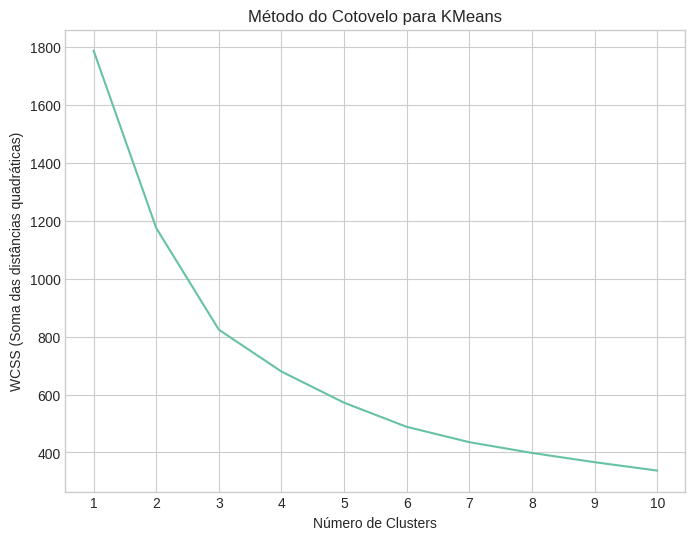

In [17]:
# 1. Método do Cotovelo para determinar o número ideal de clusters (de 1 a 10)
wcss = []  # Lista para armazenar os valores do WCSS
for i in range(1, 11):  # Tentando clusters de 1 a 10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_normalizado)  # Usando o X_normalizado para o ajuste
    wcss.append(kmeans.inertia_)  # Calculando a inércia (WCSS) e armazenando

# 2. Gráfico do Método do Cotovelo
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss)  # Gráfico de WCSS por número de clusters
plt.title('Método do Cotovelo para KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Soma das distâncias quadráticas)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


# Clusterizações (Kmeans, DBscan, Hierarquico)

## Kmeans

In [18]:
# Verificar os tipos de dados e garantir que são numéricos
print(df_base[colunas_para_normalizar].dtypes)

# Verificar se há valores nulos (NaN)
print(df_base[colunas_para_normalizar].isnull().sum())

# Caso existam NaNs, podemos preencher com a média:
df_base[colunas_para_normalizar] = df_base[colunas_para_normalizar].fillna(df_base[colunas_para_normalizar].mean())

# Normalizar os dados novamente, caso tenha preenchido NaN
scaler = StandardScaler()
X_normalizado = scaler.fit_transform(df_base[colunas_para_normalizar])

# Agora, rodamos o KMeans com os dados limpos e normalizados
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_normalizado)


DELTA_IDEB         float64
DELTA_MT           float64
DELTA_LP           float64
DELTA_APROVACAO    float64
dtype: object
DELTA_IDEB         270
DELTA_MT           270
DELTA_LP           270
DELTA_APROVACAO    262
dtype: int64


DELTA_IDEB         float64
DELTA_MT           float64
DELTA_LP           float64
DELTA_APROVACAO    float64
dtype: object
DELTA_IDEB         0
DELTA_MT           0
DELTA_LP           0
DELTA_APROVACAO    0
dtype: int64


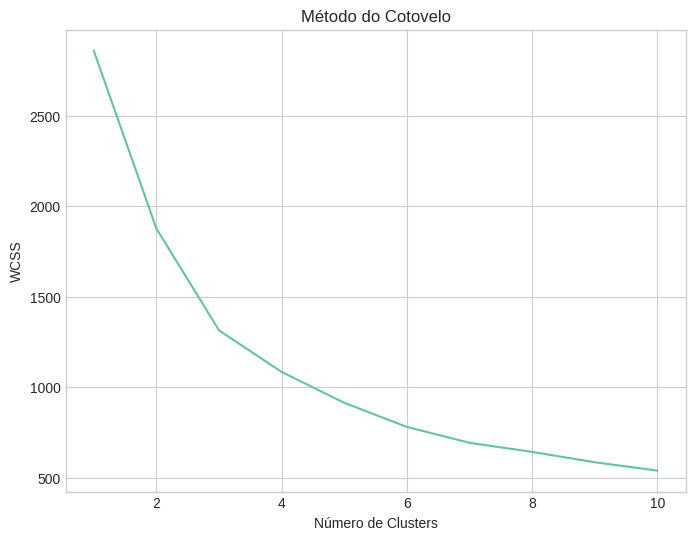

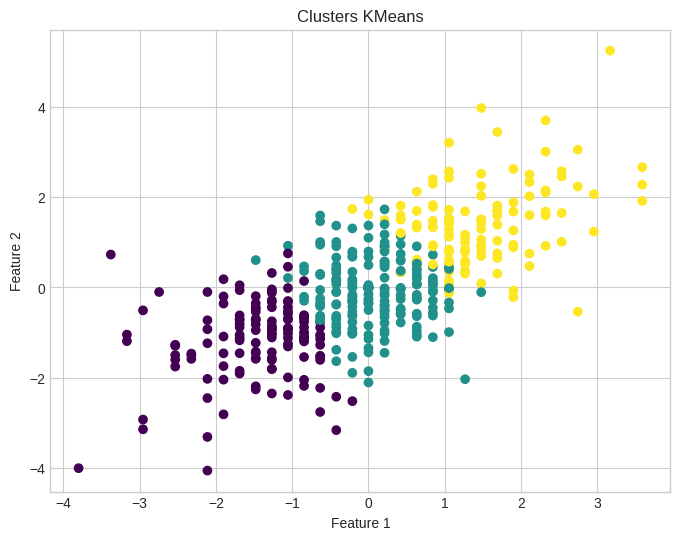

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Verificando os tipos de dados e valores nulos
print(df_base[colunas_para_normalizar].dtypes)
print(df_base[colunas_para_normalizar].isnull().sum())  # Verificando valores nulos

# Preenchendo valores nulos com a média
df_base[colunas_para_normalizar] = df_base[colunas_para_normalizar].fillna(df_base[colunas_para_normalizar].mean())

# Normalizando os dados novamente, se necessário
scaler = StandardScaler()
X_normalizado = scaler.fit_transform(df_base[colunas_para_normalizar])

# Rodando o KMeans com o número de clusters desejado
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_normalizado)  # Previsões dos clusters

# Plotando os resultados do método do cotovelo (se necessário, para determinar K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_normalizado)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss)
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# Plotando os clusters em 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_normalizado[:, 0], X_normalizado[:, 1], c=y_kmeans, cmap='viridis')
plt.title('Clusters KMeans')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


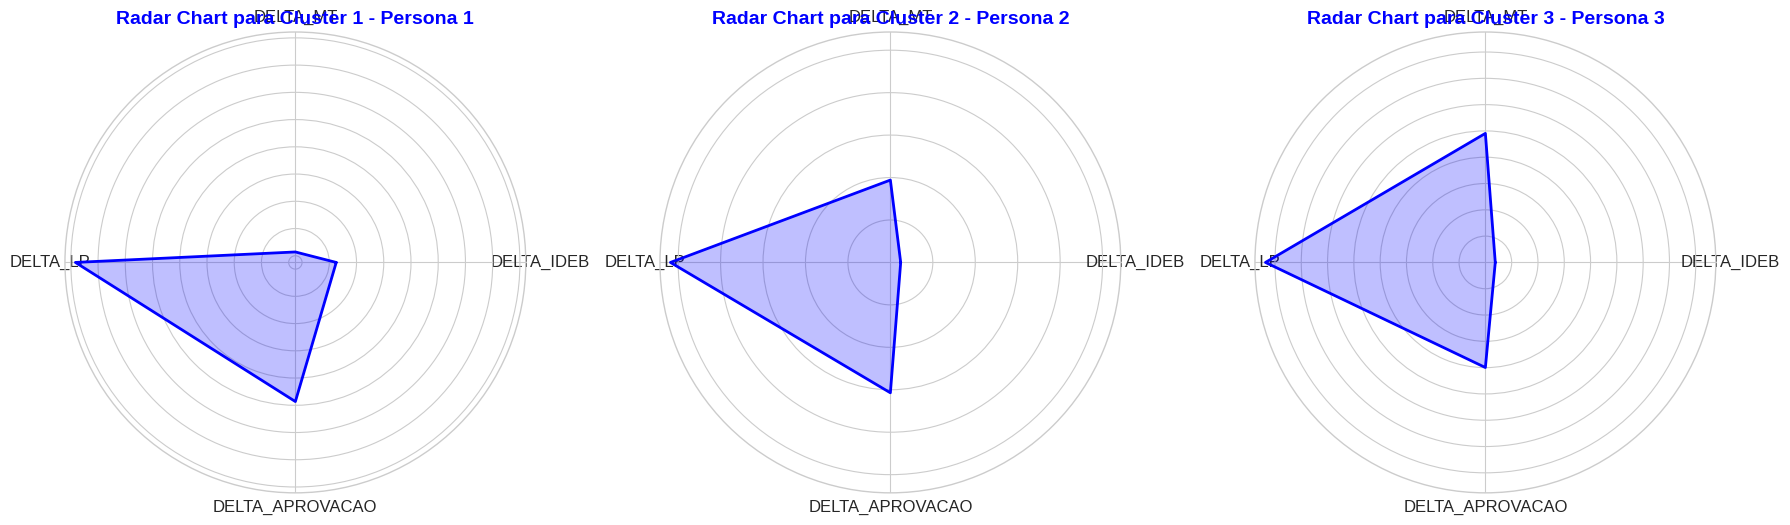

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Selecionando as colunas para análise
colunas_para_radar = ['DELTA_IDEB', 'DELTA_MT', 'DELTA_LP', 'DELTA_APROVACAO']

# Definir o número de clusters (já sabemos que são 3 clusters no KMeans)
n_clusters = 3

# Definir a quantidade de colunas (para colocarmos os gráficos lado a lado)
fig, axs = plt.subplots(1, n_clusters, figsize=(18, 6), subplot_kw=dict(polar=True))

# Criar o gráfico de radar para cada cluster
for i in range(n_clusters):
    # Filtrando os dados para o cluster i
    cluster_data = df_base[y_kmeans == i][colunas_para_radar].mean()

    # Criando o gráfico de radar
    categories = cluster_data.index
    values = cluster_data.values

    # Número de variáveis
    num_vars = len(categories)

    # Angulação de cada eixo do gráfico
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # O gráfico será um círculo, então fechamos a forma (voltamos ao ponto de origem)
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    # Criando o gráfico de radar e ajustando o título
    axs[i].fill(angles, values, color='blue', alpha=0.25)
    axs[i].plot(angles, values, color='blue', linewidth=2)  # Linhas do gráfico
    axs[i].set_yticklabels([])  # Remove os rótulos do eixo Y
    axs[i].set_xticks(angles[:-1])
    axs[i].set_xticklabels(categories, fontsize=12)
    axs[i].set_title(f"Radar Chart para Cluster {i+1} - Persona {i+1}", size=14, color='blue', fontweight='bold')

# Ajustando o layout dos gráficos
plt.tight_layout()
plt.show()


## Dbscan

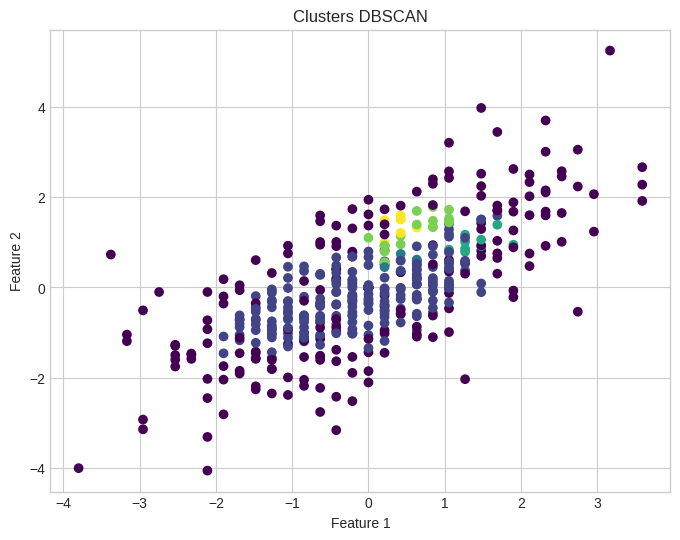

In [21]:
from sklearn.cluster import DBSCAN

# Rodando o DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_normalizado)

# Visualizando os clusters DBSCAN
plt.figure(figsize=(8, 6))
plt.scatter(X_normalizado[:, 0], X_normalizado[:, 1], c=y_dbscan, cmap='viridis')
plt.title('Clusters DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


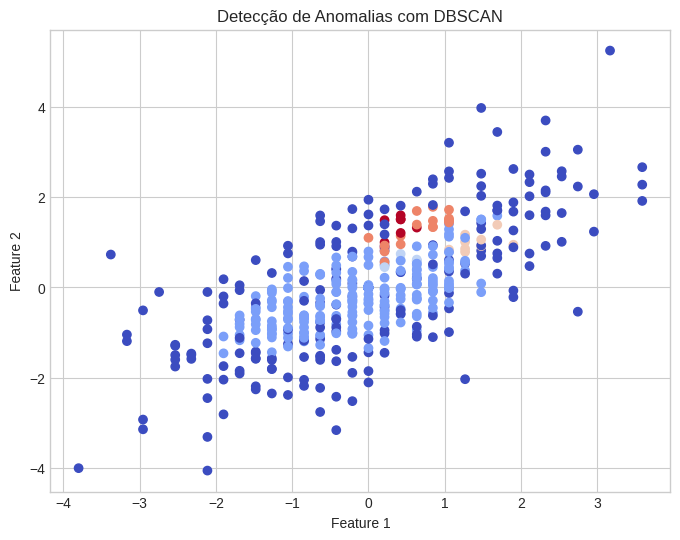

In [22]:
from sklearn.cluster import DBSCAN

# Inicializando DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Ajustando o DBSCAN
y_dbscan = dbscan.fit_predict(X_normalizado)

# Visualizando as anomalias
plt.figure(figsize=(8, 6))
plt.scatter(X_normalizado[:, 0], X_normalizado[:, 1], c=y_dbscan, cmap='coolwarm')
plt.title('Detecção de Anomalias com DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


## Hierarquico

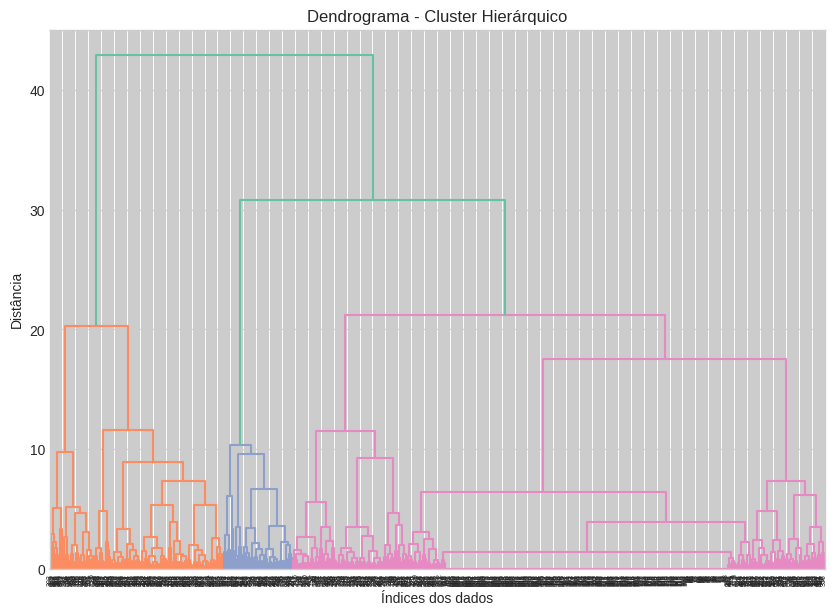

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Rodando o Cluster Hierárquico
linked = linkage(X_normalizado, 'ward')

# Gerando o dendrograma
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrograma - Cluster Hierárquico')
plt.xlabel('Índices dos dados')
plt.ylabel('Distância')
plt.show()


# Detecção de anomalias - Isolation Forest

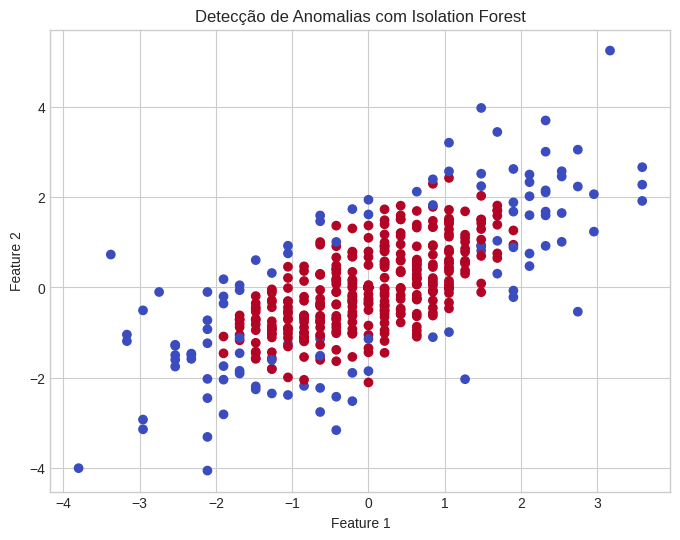

In [24]:
from sklearn.ensemble import IsolationForest

# Inicializando o modelo de Isolation Forest
model_iforest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)

# Ajustando o modelo nos dados normalizados
model_iforest.fit(X_normalizado)

# Prevendo as anomalias (1 é normal, -1 é anômalo)
y_anomaly = model_iforest.predict(X_normalizado)

# Visualizando as anomalias em um gráfico de dispersão
plt.figure(figsize=(8, 6))
plt.scatter(X_normalizado[:, 0], X_normalizado[:, 1], c=y_anomaly, cmap='coolwarm', marker='o')
plt.title('Detecção de Anomalias com Isolation Forest')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
